In [12]:
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
from network import NestedSpectralPartition

# HCP FC data for 753 subjects
fc = loadmat('data/FC_rs')["FC_rs"].T
fc_master = np.mean(fc, axis=0) # Approximate stable FC matrix

print(fc.shape)         # (753, 400, 400)
print(fc_master.shape)  # (400, 400)

(753, 400, 400)
(400, 400)


Comet implementation:

In [7]:
nsp = NestedSpectralPartition(fc)
nsp.estimate()
nsp.calibrate(fc_master)



100%|██████████| 753/753 [01:12<00:00, 10.33it/s]


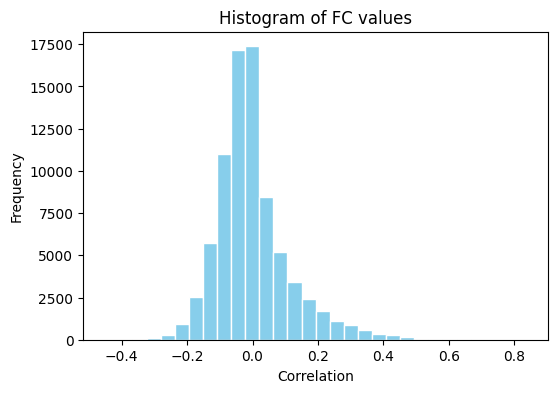

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the FC matrix to get all edge values (use only upper triangle to avoid duplicates)
fc_values = fc_master[np.triu_indices_from(fc_master, k=1)]

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(fc_values, bins=30, color='skyblue', edgecolor='white')
plt.title("Histogram of FC values")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.show()

Compare results between original and new implementation:

In [ ]:
from numpy import linalg as LA

def hierarchichal_clustering(fc_mat):
    '''Compute spectral clusters and return the number of clusters and their size at every level'''
    fc_mat = fc_mat.copy()
    NB_ROI = fc_mat.shape[0]
    fc_mat[fc_mat<0]=0
    _, modes = LA.eigh(fc_mat)
    modes = np.fliplr(modes).T

    clus_num = [] #Number of clusters for each order
    clus_size = [] #Elements are arrays of cluster size for each order
    clusters = [] #Elements are arrays of positions for each clusters in the previous order
    clus_num.append(1) #First mode only has one module
    clus_size.append([NB_ROI]) #First mode has one module of size NB_ROI

    clusters.append((modes[1]<0).nonzero()) #Initialize clusters of 2nd mode
    clusters.append((modes[1]>=0).nonzero())
    clus_num.append(2) #The 2nd mode always has 2 clusters (1 pos and 1neg)

    for order in range(2,NB_ROI):
        x = (modes[order]>=0).nonzero() #Get indices for positive values
        y = (modes[order]<0).nonzero() #Get indices for negative values
        length = []
        new_clus = []
        for cluster in clusters: #Find clusters of mode N
            length.append(np.size(cluster)) #Find length of clusters at order-1
            if np.size(cluster)<=1:
                new_clus.append(cluster)
            else:
                if np.size(np.intersect1d(x,cluster)) >= 1 : new_clus.append(np.intersect1d(x,cluster))
                if np.size(np.intersect1d(y,cluster)) >= 1 : new_clus.append(np.intersect1d(y,cluster))
        clus_size.append(length)
        clusters = new_clus #Update new cluster
        clus_num.append(len(clusters))
    #Find length of clusters at order=NB_ROI
    length=[]
    for cluster in clusters:
        length.append(np.size(cluster))
    clus_size.append(length)
    return clus_size, clus_num

def segint_component(fc, clus_size, clus_num):
    '''Given the spectral cluster, compute the integration and segregation components'''
    fc = fc.copy()
    NB_ROI = fc.shape[0]
    clus_num = np.divide(clus_num, NB_ROI)
    fc = (fc + fc.T)/2
    fc[fc<0] = 0
    evals, modes = LA.eigh(fc)
    evals[evals<0] = 0
    evals = np.flip(np.square(evals))
    p=np.zeros(NB_ROI)
    hf=np.zeros(NB_ROI)    #Compute correction p
    for i in range(0,NB_ROI):
        c = 1/clus_num[i]
        p[i] = np.sum(abs(np.asarray(clus_size[i])-c)/NB_ROI)
    for i in range(0,NB_ROI):
        hf[i] = evals[i] * clus_num[i] * (1-p[i])
    hin = hf[0]/NB_ROI
    hse = np.sum(hf[1:])/NB_ROI
    return hin, hse

def stable_correct(sub_idx, sFC, hin, hseg):
    """
    input:
        sub_idx : integer index of the subject (0-based)
        sFC     : stable FC matrix
        hin     : list/array of H_In per subject
        hseg    : list/array of H_Se per subject
    output:
        Hin_cal, Hse_cal : calibrated H_In / H_Se for that subject
    """
    # Stable components from stable FC
    Clus_size, Clus_num = hierarchichal_clustering(sFC)
    R_IN, R_IM = segint_component(sFC, Clus_size, Clus_num)

    hin = np.asarray(hin)
    hseg = np.asarray(hseg)

    # Proportional calibration (same as we derived)
    p2 = (hseg.mean() - R_IN) / hseg.mean()
    Hse_cal = hseg[sub_idx] * (1.0 - p2)

    p1 = (hin.mean() - R_IN) / hin.mean()
    Hin_cal = hin[sub_idx] * (1.0 - p1)

    return Clus_num, Clus_size, Hin_cal, Hse_cal, [p1, p2]

#################
# COMPARE METHODS

#############
# Wang et al.
H_In_wang = []
H_Se_wang = []
H_B_wang = []

for input_fc in fc[:5,:,:]:
    clus_size, clus_num = hierarchichal_clustering(input_fc)
    H_In, H_Se = segint_component(input_fc, clus_size, clus_num)
    H_In_wang.append(H_In)
    H_Se_wang.append(H_Se)
    H_B_wang.append(H_In - H_Se)

H_B_wang_stable = []
for sub in range(5):
    _, _, Hin_cal, Hse_cal, _ = stable_correct(sub, fc_master, H_In_wang, H_Se_wang)
    H_B_wang_stable.append(Hin_cal - Hse_cal)

#######
# Comet
nsp = NestedSpectralPartition(fc[:5,:,:])
nsp.estimate()
nsp.calibrate(fc_master)

print("Balance Wang:    ", np.asarray(H_B_wang))
print("Balance Comet:   ", nsp.H_B)
print("")
print("Calibrated Wang: ", np.asarray(H_B_wang_stable))
print("Calibrated Comet:", nsp.H_B_cal)

100%|██████████| 5/5 [00:00<00:00, 10.56it/s]

Balance Wang:     [-0.76967256 -0.70041177 -0.77992522 -0.7399288  -0.73116563]
Balance Comet:    [-0.76967256 -0.70041177 -0.77992522 -0.7399288  -0.73116563]

Calibrated Wang:  [-5.42632194e-05  1.68705231e-04 -8.42553633e-05  2.05098337e-04
 -2.35284985e-04]
Calibrated Comet: [-5.42632194e-05  1.68705231e-04 -8.42553633e-05  2.05098337e-04
 -2.35284985e-04]
